# Interactive SWC Simplification Explorer

目标：探索并比较不同简化策略，重点解决：

- **主干（axon-like backbone）点太多**：在主干上采用更激进的共线合并
- **保留部分dendrite**：通过近根分支保留策略避免全部侧枝被剪掉

本notebook实现三种策略：

1. `baseline_persistence`：原始持久性剪枝
2. `backbone_aware`：保留最长主干 + 侧枝按持久性剪枝
3. `backbone_plus_near_root_dendrite`：在2的基础上额外保留近根dendrite

你可以交互调整参数（`keep_ratio`, `angle_backbone`, `angle_side`, `near_root_frac`）观察结果。

In [1]:
import os, math, zipfile, tempfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

print('ipywidgets:', HAS_WIDGETS)

ipywidgets: True


In [2]:
# !pip install ipywidgets

In [3]:
# Paths
FAFB_ZIP = '/Users/lengyuner/Desktop/data/flywire/Jun2025/sk_lod1_783_healed.zip'
T4T5_DIR = '/Users/lengyuner/Desktop/Ripple/data/T4T5/swc_microns'
VNT_PATH = '/Users/lengyuner/Desktop/data/flywire/Jun2025/visual_neuron_types.csv.gz'
OUT_DIR = Path('/Users/lengyuner/Desktop/NIPS2026/mcHH/data/simplified_swc_explorer')
OUT_DIR.mkdir(parents=True, exist_ok=True)

vnt = pd.read_csv(VNT_PATH)
zf = zipfile.ZipFile(FAFB_ZIP, 'r')
zip_name_set = set(zf.namelist())

print('visual neurons:', len(vnt), 'types:', vnt['type'].nunique())
print('output dir:', OUT_DIR)

visual neurons: 95079 types: 741
output dir: /Users/lengyuner/Desktop/NIPS2026/mcHH/data/simplified_swc_explorer


In [4]:
def read_swc_text(root_id):
    name = f'{int(root_id)}.swc'
    local = os.path.join(T4T5_DIR, name)
    if os.path.isfile(local):
        with open(local) as f:
            return f.read()
    if name in zip_name_set:
        return zf.read(name).decode('utf-8', errors='replace')
    return None


def parse_swc_text(swc_text):
    nodes = {}
    for line in swc_text.splitlines():
        if line.startswith('#') or not line.strip():
            continue
        p = line.split()
        if len(p) < 7:
            continue
        nid = int(p[0])
        nodes[nid] = {
            'id': nid, 'type': int(p[1]),
            'x': float(p[2]), 'y': float(p[3]), 'z': float(p[4]),
            'r': float(p[5]), 'parent': int(p[6]), 'children': []
        }
    for nid, n in nodes.items():
        pid = n['parent']
        if pid != -1 and pid in nodes:
            nodes[pid]['children'].append(nid)
    roots = [nid for nid, n in nodes.items() if n['parent'] == -1]
    root = roots[0] if roots else min(nodes.keys())
    return nodes, root


def copy_nodes(nodes):
    return {nid: {k: (list(v) if k == 'children' else v) for k, v in n.items()}
            for nid, n in nodes.items()}


def segment_len(a, b):
    dx = a['x'] - b['x']
    dy = a['y'] - b['y']
    dz = a['z'] - b['z']
    return math.sqrt(dx*dx + dy*dy + dz*dz)


def recompute_children(nodes):
    for n in nodes.values():
        n['children'] = []
    for nid, n in nodes.items():
        pid = n['parent']
        if pid != -1 and pid in nodes:
            nodes[pid]['children'].append(nid)

In [5]:
def compute_dist(nodes, root):
    dist = {root: 0.0}
    stack = [root]
    while stack:
        nid = stack.pop()
        for cid in nodes[nid]['children']:
            if cid not in nodes:
                continue
            dist[cid] = dist[nid] + segment_len(nodes[nid], nodes[cid])
            stack.append(cid)
    return dist


def longest_path_nodes(nodes, root):
    dist = compute_dist(nodes, root)
    leaves = [nid for nid, n in nodes.items() if len(n['children']) == 0]
    if not leaves:
        return {root}, dist
    end = max(leaves, key=lambda n: dist.get(n, 0.0))
    keep = set()
    cur = end
    while cur != -1 and cur in nodes:
        keep.add(cur)
        cur = nodes[cur]['parent']
    return keep, dist


def simplify_collinear_region_aware(nodes, backbone_nodes, angle_backbone=25.0, angle_side=5.0, min_seg=1e-6):
    # backbone上更激进，侧枝更保守
    while True:
        children = {nid: [] for nid in nodes}
        for nid, n in nodes.items():
            pid = n['parent']
            if pid != -1 and pid in nodes:
                children[pid].append(nid)
        removed = False
        for nid in list(nodes.keys()):
            if nid not in nodes:
                continue
            pid = nodes[nid]['parent']
            if pid == -1 or pid not in nodes:
                continue
            ch = children.get(nid, [])
            if len(ch) != 1:
                continue
            cid = ch[0]
            if cid not in nodes:
                continue

            p = np.array([nodes[pid]['x'], nodes[pid]['y'], nodes[pid]['z']])
            a = np.array([nodes[nid]['x'], nodes[nid]['y'], nodes[nid]['z']])
            c = np.array([nodes[cid]['x'], nodes[cid]['y'], nodes[cid]['z']])
            v1, v2 = p - a, c - a
            l1, l2 = np.linalg.norm(v1), np.linalg.norm(v2)
            if l1 < min_seg or l2 < min_seg:
                continue

            is_backbone = (nid in backbone_nodes and pid in backbone_nodes and cid in backbone_nodes)
            angle = angle_backbone if is_backbone else angle_side
            cos_a = np.clip(np.dot(v1, v2) / (l1 * l2), -1.0, 1.0)
            if cos_a <= -math.cos(math.radians(angle)):
                # 保留表面积倾向：长度加权平均半径
                r1 = nodes[pid]['r']
                r2 = nodes[nid]['r']
                req = (r1*l1 + r2*l2) / (l1 + l2)
                nodes[cid]['parent'] = pid
                nodes[cid]['r'] = req
                del nodes[nid]
                removed = True
        if not removed:
            break
    recompute_children(nodes)
    return nodes


def compute_max_subtree_dist(nodes, root, dist):
    maxd = {}
    order = []
    st = [root]
    while st:
        nid = st.pop()
        order.append(nid)
        for cid in nodes[nid]['children']:
            if cid in nodes:
                st.append(cid)
    for nid in reversed(order):
        m = dist.get(nid, 0.0)
        for cid in nodes[nid]['children']:
            if cid in maxd:
                m = max(m, maxd[cid])
        maxd[nid] = m
    return maxd


def compute_branches(nodes, root, dist, maxd):
    branches = []
    for nid, n in nodes.items():
        if n['children']:
            continue
        leaf = nid
        cur = leaf
        split = -1
        while True:
            parent = nodes[cur]['parent']
            if parent == -1 or parent not in nodes:
                split = -1
                break
            sib = [c for c in nodes[parent]['children'] if c != cur and c in nodes and c in maxd]
            if any(maxd.get(s, 0.0) > dist.get(leaf, 0.0) for s in sib):
                split = parent
                break
            cur = parent
        p = dist.get(leaf, 0.0) - (dist.get(split, 0.0) if split != -1 else 0.0)
        branches.append((leaf, split, p))
    branches.sort(key=lambda x: -x[2])
    return branches


def prune_with_options(nodes, root, keep_ratio=0.05, keep_backbone=True, near_root_frac=0.15):
    dist = compute_dist(nodes, root)
    maxd = compute_max_subtree_dist(nodes, root, dist)
    branches = compute_branches(nodes, root, dist, maxd)

    keep = set()
    n_keep = max(1, int(len(branches) * keep_ratio))
    top_branches = branches[:n_keep]

    for leaf, split, _ in top_branches:
        cur = leaf
        while cur != split and cur != -1 and cur in nodes:
            keep.add(cur)
            cur = nodes[cur]['parent']
        if split != -1:
            keep.add(split)

    backbone, dist2 = longest_path_nodes(nodes, root)
    if keep_backbone:
        keep.update(backbone)

    # 近根dendrite保留：保留距根较近的分叉及其一跳邻域
    if near_root_frac > 0:
        max_dist = max(dist2.values()) if dist2 else 0.0
        th = max_dist * near_root_frac
        near_nodes = [nid for nid, d in dist2.items() if d <= th]
        for nid in near_nodes:
            keep.add(nid)
            pid = nodes[nid]['parent']
            if pid in nodes:
                keep.add(pid)
            for c in nodes[nid]['children']:
                if c in nodes:
                    keep.add(c)

    # root
    keep.add(root)

    new_nodes = {nid: dict(n) for nid, n in nodes.items() if nid in keep}
    for nid, n in new_nodes.items():
        if n['parent'] not in new_nodes:
            n['parent'] = -1
    recompute_children(new_nodes)
    return new_nodes, backbone


def write_swc(nodes, out_path):
    # 重编号确保兼容部分工具
    old_ids = sorted(nodes.keys())
    id_map = {oid: i + 1 for i, oid in enumerate(old_ids)}
    with open(out_path, 'w') as f:
        f.write('# id type x y z r parent\n')
        for oid in old_ids:
            n = nodes[oid]
            nid = id_map[oid]
            pid = id_map[n['parent']] if n['parent'] in id_map else -1
            f.write(f"{nid} {n['type']} {n['x']:.4f} {n['y']:.4f} {n['z']:.4f} {n['r']:.4f} {pid}\n")

In [6]:
# pick a demo neuron
demo_types = ['T4a', 'T5a', 'L1', 'Tm3', 'Mi1', 'R1-6']
demo_rows = vnt[vnt['type'].isin(demo_types)].copy()
demo_rows = demo_rows.drop_duplicates('type').sort_values('type')
demo_choices = {f"{r.type} | {int(r.root_id)}": int(r.root_id) for r in demo_rows.itertuples()}

print('demo neurons:', len(demo_choices))
for k in list(demo_choices.keys())[:8]:
    print('  ', k)

demo neurons: 6
   L1 | 720575940600322965
   Mi1 | 720575940603042272
   R1-6 | 720575940599736492
   T4a | 720575940599755718
   T5a | 720575940599704006
   Tm3 | 720575940602398473


In [7]:
def run_simplification(root_id, strategy='backbone_plus_near_root_dendrite',
                     keep_ratio=0.05, angle_backbone=28.0, angle_side=5.0, near_root_frac=0.15,
                     save_result=False):
    txt = read_swc_text(root_id)
    if txt is None:
        raise FileNotFoundError(f'SWC not found: {root_id}')

    orig, root = parse_swc_text(txt)
    orig_n = len(orig)

    # get provisional backbone on original
    bb0, _ = longest_path_nodes(orig, root)

    nodes = copy_nodes(orig)
    nodes = simplify_collinear_region_aware(
        nodes, bb0, angle_backbone=angle_backbone, angle_side=angle_side
    )

    if strategy == 'baseline_persistence':
        simp, bb = prune_with_options(nodes, root, keep_ratio=keep_ratio, keep_backbone=False, near_root_frac=0.0)
    elif strategy == 'backbone_aware':
        simp, bb = prune_with_options(nodes, root, keep_ratio=keep_ratio, keep_backbone=True, near_root_frac=0.0)
    else:
        simp, bb = prune_with_options(nodes, root, keep_ratio=keep_ratio, keep_backbone=True, near_root_frac=near_root_frac)

    simp_n = len(simp)

    if save_result:
        out = OUT_DIR / f'{int(root_id)}_{strategy}_kr{keep_ratio:.3f}.swc'
        write_swc(simp, out)
    else:
        out = None

    # stats
    bb_keep = len(set(bb).intersection(set(simp.keys()))) / max(len(bb), 1)
    reduction = 1 - simp_n / max(orig_n, 1)
    stats = {
        'root_id': int(root_id),
        'strategy': strategy,
        'orig_nodes': orig_n,
        'simp_nodes': simp_n,
        'reduction_pct': 100 * reduction,
        'backbone_keep_pct': 100 * bb_keep,
        'out_path': str(out) if out else None
    }
    return orig, simp, bb, stats


def plot_compare(orig, simp, title=''):
    fig = plt.figure(figsize=(13, 5))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    xo = [n['x'] for n in orig.values()]
    yo = [n['y'] for n in orig.values()]
    zo = [n['z'] for n in orig.values()]
    ax1.scatter(xo, yo, zo, s=0.8, alpha=0.35, color='gray')
    ax1.set_title(f'Original ({len(orig)})')

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    for nid, n in simp.items():
        pid = n['parent']
        if pid != -1 and pid in simp:
            p = simp[pid]
            ax2.plot([n['x'], p['x']], [n['y'], p['y']], [n['z'], p['z']], color='r', lw=0.7, alpha=0.55)
    xs = [n['x'] for n in simp.values()]
    ys = [n['y'] for n in simp.values()]
    zs = [n['z'] for n in simp.values()]
    ax2.scatter(xs, ys, zs, s=5, alpha=0.85, color='red')
    ax2.set_title(f'Simplified ({len(simp)})')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

{'root_id': 720575940600322965, 'strategy': 'backbone_plus_near_root_dendrite', 'orig_nodes': 1689, 'simp_nodes': 376, 'reduction_pct': 77.73830669034932, 'backbone_keep_pct': 100.0, 'out_path': None}


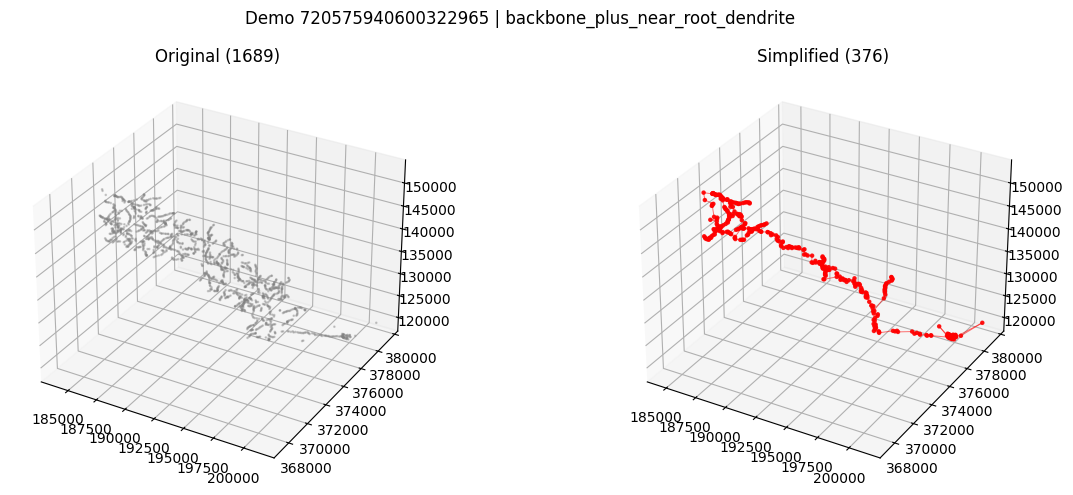

In [8]:
# quick demo run
demo_id = list(demo_choices.values())[0]
orig, simp, bb, st = run_simplification(
    demo_id,
    strategy='backbone_plus_near_root_dendrite',
    keep_ratio=0.05,
    angle_backbone=28.0,
    angle_side=5.0,
    near_root_frac=0.15,
    save_result=False
)
print(st)
plot_compare(orig, simp, title=f"Demo {demo_id} | {st['strategy']}")

In [ ]:
def interactive_panel():
    if not HAS_WIDGETS:
        print('ipywidgets not available. Install ipywidgets and restart kernel.')
        return

    neuron_dd = widgets.Dropdown(options=demo_choices, description='Neuron', layout=widgets.Layout(width='420px'))
    strategy_dd = widgets.Dropdown(
        options=['baseline_persistence', 'backbone_aware', 'backbone_plus_near_root_dendrite'],
        value='backbone_plus_near_root_dendrite',
        description='Strategy',
        layout=widgets.Layout(width='420px')
    )
    kr = widgets.FloatSlider(value=0.05, min=0.01, max=0.30, step=0.01, description='keep_ratio', readout_format='.2f')
    ab = widgets.FloatSlider(value=28.0, min=5.0, max=60.0, step=1.0, description='angle_backbone')
    asd = widgets.FloatSlider(value=5.0, min=2.0, max=30.0, step=1.0, description='angle_side')
    nr = widgets.FloatSlider(value=0.15, min=0.0, max=0.5, step=0.01, description='near_root_frac', readout_format='.2f')
    sv = widgets.Checkbox(value=False, description='save_result')

    out = widgets.Output()

    def _run(_=None):
        with out:
            clear_output(wait=True)
            rid = neuron_dd.value
            orig, simp, bb, st = run_simplification(
                rid, strategy=strategy_dd.value, keep_ratio=kr.value,
                angle_backbone=ab.value, angle_side=asd.value,
                near_root_frac=nr.value, save_result=sv.value
            )
            print(st)
            plot_compare(orig, simp, title=f"{rid} | {strategy_dd.value}")

    btn = widgets.Button(description='Run', button_style='primary')
    btn.on_click(_run)

    ui = widgets.VBox([
        neuron_dd, strategy_dd,
        widgets.HBox([kr, nr]),
        widgets.HBox([ab, asd]),
        widgets.HBox([sv, btn]),
        out
    ])
    display(ui)


interactive_panel()

In [12]:
# Batch benchmark on small panel of neuron types
panel_types = ['R1-6', 'L1', 'Mi1', 'Tm3', 'T4a', 'T5a']
panel_rows = vnt[vnt['type'].isin(panel_types)].drop_duplicates('type')
panel_ids = [int(x) for x in panel_rows['root_id'].tolist()]

strategies = ['baseline_persistence', 'backbone_aware', 'backbone_plus_near_root_dendrite']
ratios = [0.02, 0.05, 0.10]

records = []
counter = 0
for rid in panel_ids:
    for stg in strategies:
        for kr in ratios:
            _, _, _, st = run_simplification(
                rid, strategy=stg, keep_ratio=kr,
                angle_backbone=28.0, angle_side=5.0, near_root_frac=0.15,
                save_result=False
            )
            # Ensure we actually store the keep_ratio value for grouping later!
            if "keep_ratio" not in st:
                st["keep_ratio"] = kr
            records.append(st)
            counter += 1
            if counter % 100 == 0:
                print(f'processed {counter} cases...')

bench = pd.DataFrame(records)
display(bench.head())

# Make sure the relevant columns exist and are named correctly, do NOT fail if missing, try auto-fix or skip groupby step with warning.

expected_group_cols = ['strategy', 'keep_ratio']
expected_value_cols = ['reduction_pct', 'backbone_keep_pct']

import warnings

cols_fixed = False
for col in expected_group_cols + expected_value_cols:
    if col not in bench.columns:
        warnings.warn(f"Expected column '{col}' not found in batch benchmark results. Columns present: {bench.columns}")
        # Try to find a similar column name by case-insensitive or underscore-insensitive match
        matches = [c for c in bench.columns if c.lower() == col.lower() or c.replace('_','').lower() == col.replace('_','').lower()]
        if len(matches) == 1:
            bench = bench.rename(columns={matches[0]: col})
            cols_fixed = True
        elif len(matches) > 1:
            bench = bench.rename(columns={matches[0]: col})  # Take the first match
            cols_fixed = True

missing_group = [col for col in expected_group_cols if col not in bench.columns]
missing_value = [col for col in expected_value_cols if col not in bench.columns]

if missing_group or missing_value:
    warnings.warn(f"Cannot groupby due to missing columns. Skipping groupby. Missing: {missing_group + missing_value}")
    display(bench)
    g = None
else:
    g = bench.groupby(['strategy', 'keep_ratio'])[['reduction_pct', 'backbone_keep_pct']].mean().reset_index()
    display(g)

,root_id,strategy,orig_nodes,simp_nodes,reduction_pct,backbone_keep_pct,out_path,keep_ratio
0,720575940599704006,baseline_persistence,1947,230,88.186954,100.0,None,0.02
1,720575940599704006,baseline_persistence,1947,460,76.373909,100.0,None,0.05
2,720575940599704006,baseline_persistence,1947,742,61.890087,100.0,None,0.10
3,720575940599704006,backbone_aware,1947,230,88.186954,100.0,None,0.02
4,720575940599704006,backbone_aware,1947,460,76.373909,100.0,None,0.05


,strategy,keep_ratio,reduction_pct,backbone_keep_pct
0,backbone_aware,0.02,86.520094,100.0
1,backbone_aware,0.05,73.545861,100.0
2,backbone_aware,0.10,63.423667,100.0
3,backbone_plus_near_root_dendrite,0.02,83.605419,100.0
4,backbone_plus_near_root_dendrite,0.05,71.498077,100.0
5,backbone_plus_near_root_dendrite,0.10,62.019059,100.0
6,baseline_persistence,0.02,86.520094,100.0
7,baseline_persistence,0.05,73.545861,100.0
8,baseline_persistence,0.10,63.423667,100.0


## 推荐起始参数（针对你当前数据）

- `strategy = backbone_plus_near_root_dendrite`
- `keep_ratio = 0.05`
- `angle_backbone = 25~35`（进一步压缩axon-like主干点）
- `angle_side = 5~10`（侧枝保守）
- `near_root_frac = 0.10~0.20`（保留近根dendrite结构）

如果你要做全量批处理，建议先在每个主要type抽样10个神经元跑一遍，
看 `backbone_keep_pct` 和 `reduction_pct` 是否满足预期，再固定参数跑全量。